In [1]:
%matplotlib inline
import filtering
from datetime import timedelta
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from netCDF4 import Dataset

/meddy/simingzhang/Analysis/python/python3/lagrangian-filtering/filtering/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
INFO: Compiled ParcelsRandom ==> /tmp/parcels-979991/libparcels_random_45f90ab5-e684-4f3f-97de-c079d4411371.so


Construct a simple analytic flow involving a mean $U_0$, wave $U_w$ and eddy $\psi$ flow:

$U=U_0+U_w \, \sin{kx} + \frac{\partial \psi}{\partial y}$

$V=\frac{f U_w}{k U_0} \, \cos{kx} - \frac{\partial \psi}{\partial x}$

where

$\psi=U_e \, L_e \, \exp{(-((x- U_0 t)^2+(y- y_0)^2)/L_e^2)}$

The wave is propagating against the flow, and is thus trapped and steady ($k U_0>f$). A common example of this is a lee wave.

In [2]:
U0=0.2
Uw=0.01
Ue=0.01
f=5e-5
k=1e-3
Le=10e3;

# Periodic grids
Lx=8*2*np.pi/k
x=np.linspace(0,Lx,200,endpoint=False)
y=np.copy(x)
ym=np.mean(y);
# Time - 2 weeks
t=np.array(range(0,(2*7*24*60**2),3600))

T,Y,X=np.meshgrid(t,y,x,indexing='ij')

# estimate of the time taken to advect 1 grid cell
(x[2]-x[1])/U0
# estimate of "frequency" of eddy
U0/Le

2e-05

In [3]:
# Generate the flow, accounting for periodicity
xc=(U0*t % Lx)[:,None,None]
ut1=-2*Ue/Le*(X-xc)*np.exp(-((X-xc)**2+(Y-ym)**2)/Le**2)
vt1=2*Ue/Le*(Y-ym)*np.exp(-((X-xc)**2+(Y-ym)**2)/Le**2)
ut2=-2*Ue/Le*(X-(xc+x[-1]))*np.exp(-((X-(xc+x[-1]))**2+(Y-ym)**2)/Le**2)
vt2=2*Ue/Le*(Y-ym)*np.exp(-((X-(xc+x[-1]))**2+(Y-ym)**2)/Le**2)
ut3=-2*Ue/Le*(X+(-xc+x[-1]))*np.exp(-((X+(-xc+x[-1]))**2+(Y-ym)**2)/Le**2)
vt3=2*Ue/Le*(Y-ym)*np.exp(-((X+(-xc+x[-1]))**2+(Y-ym)**2)/Le**2)
ue=(ut1+ut2+ut3)
ve=(vt1+vt2+vt3)
# total flow
U=U0+Uw*np.sin(k*X)+ue
V=f*Uw/(k*U0)*np.cos(k*X)+ve

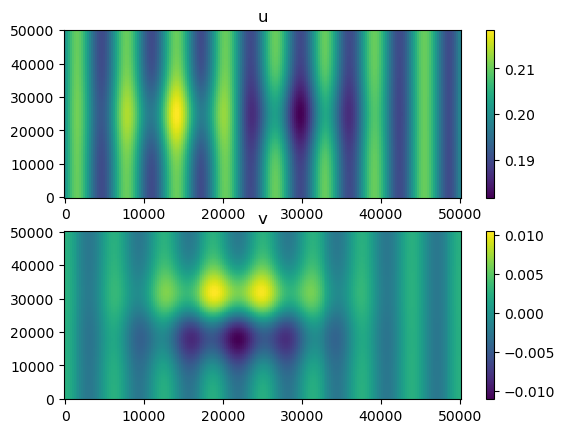

In [4]:
ti=100;
plt.subplot(2,1,1)
plt.pcolor(x,y,U[ti,:,:])
plt.title('u')
plt.colorbar()

plt.subplot(2,1,2)
plt.pcolor(x,y,V[ti,:,:])
plt.title('v');
plt.colorbar()

Now we write this test data to a netCDF before filtering

In [5]:
ncfile_name="analytic_example_input.nc"
ncfile = Dataset(ncfile_name, 'w', format='NETCDF4')
ncfile.description = 'Synthetic data for Lagrangian Filtering test'

# dimensions
ncfile.createDimension('time', None)
ncfile.createDimension('x', np.size(x))
ncfile.createDimension('y', np.size(y))

# variables
time = ncfile.createVariable('time', 'f8', ('time',))
x1 = ncfile.createVariable('x', 'f8', ('x',))
y1 = ncfile.createVariable('y', 'f8', ('y',))
U1 = ncfile.createVariable('u', 'f8', ('time', 'y', 'x'))
V1 = ncfile.createVariable('v', 'f8', ('time', 'y', 'x'))

In [6]:
U1[:] = U
V1[:] = V
time[:] = t
x1[:] = x
y1[:] = y
    
ncfile.close()

Now its time to filter...

In [7]:
filenames = {
	"U": ncfile_name, 
    "V": ncfile_name
}
variables = {"U": "u", "V": "v"}
dimensions = {"lon": "x", "lat": "y", "time": "time"}

ff = filtering.LagrangeFilter(
	"analytic_example_out1", filenames, variables, dimensions,
	sample_variables=["U","V"], mesh="flat",
	window_size=timedelta(days=3.5).total_seconds(),
    highpass_frequency=f
)

# periodic domain
ff.make_zonally_periodic()
ff.make_meridionally_periodic()

ff.advection_dt=600
t1=timedelta(days=7).total_seconds()
ff.filter(times=[t1])

INFO: Compiled SamplingParticlesample_kernel ==> /tmp/parcels-979991/0aa57d94ec69312304d8114d30926ee0_0.so
INFO:parcels.tools.loggers:Compiled SamplingParticlesample_kernel ==> /tmp/parcels-979991/0aa57d94ec69312304d8114d30926ee0_0.so
INFO: Compiled SamplingParticleAdvectionRK4sample_kernel ==> /tmp/parcels-979991/2f11c3ef0d95a566dc66a56723fd7ee2_0.so
INFO:parcels.tools.loggers:Compiled SamplingParticleAdvectionRK4sample_kernel ==> /tmp/parcels-979991/2f11c3ef0d95a566dc66a56723fd7ee2_0.so
INFO: Compiled SamplingParticleAdvectionRK4_zonally_periodic_BCsample_kernel ==> /tmp/parcels-979991/3f2625e917614d33259e563eea28df83_0.so
INFO:parcels.tools.loggers:Compiled SamplingParticleAdvectionRK4_zonally_periodic_BCsample_kernel ==> /tmp/parcels-979991/3f2625e917614d33259e563eea28df83_0.so
INFO: Compiled SamplingParticleAdvectionRK4_doubly_periodic_BCsample_kernel ==> /tmp/parcels-979991/7836a57dfd75291ee8be38bc69c25601_0.so
INFO:parcels.tools.loggers:Compiled SamplingParticleAdvectionRK4_doub

Read data back in and plot the mean and wave parts

In [8]:
ncfile_out_name="analytic_example_out1.nc"
ncfile = Dataset(ncfile_out_name, 'r', format='NETCDF4')
wave_U=ncfile.variables['var_U'][0,:,:]
wave_V=ncfile.variables['var_V'][0,:,:]
ncfile.close()

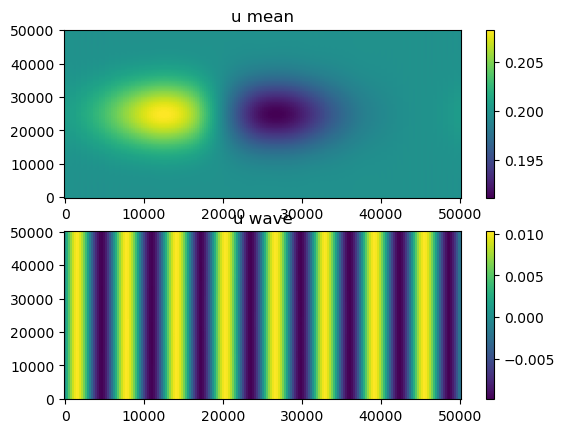

In [9]:
plt.subplot(2,1,1)
plt.pcolor(x,y,U[7*24-1,:,:]-wave_U[:])
plt.title('u mean')
plt.colorbar()

plt.subplot(2,1,2)
plt.pcolor(x,y,wave_U[:])
plt.title('u wave');
plt.colorbar()

We would like to compare the Lagrgangian filter to an Eulerian filter. First step is to make a zero velocity field.

In [184]:
ncfile_name0="analytic_example_zeros.nc"
ncfile = Dataset(ncfile_name0, 'w', format='NETCDF4')
ncfile.description = 'Synthetic data for Lagrangian Filtering test'

# dimensions
ncfile.createDimension('time', None)
ncfile.createDimension('x', np.size(x))
ncfile.createDimension('y', np.size(y))

# variables
time = ncfile.createVariable('time', 'f8', ('time',))
x1 = ncfile.createVariable('x', 'f8', ('x',))
y1 = ncfile.createVariable('y', 'f8', ('y',))
U1 = ncfile.createVariable('u', 'f8', ('time', 'y', 'x'))
V1 = ncfile.createVariable('v', 'f8', ('time', 'y', 'x'))

U1[:] = U*0
V1[:] = V*0
time[:] = t
x1[:] = x
y1[:] = y
    
ncfile.close()

Now filter with the same settings. The wave and mean flows are incorrectly identified in this case.

In [185]:
filenames = {
    "U": ncfile_name0, 
    "V": ncfile_name0,
	"U2": ncfile_name, 
    "V2": ncfile_name
}
variables = {"U": "u", "V": "v","U2": "u", "V2": "v"}
dimensions = {"lon": "x", "lat": "y", "time": "time"}

ff = filtering.LagrangeFilter(
	"analytic_example_zeros1", filenames, variables, dimensions,
	sample_variables=["U2","V2"], mesh="flat",
	window_size=timedelta(days=3.5).total_seconds(),
    highpass_frequency=f
)

# periodic domain
ff.make_zonally_periodic()
ff.make_meridionally_periodic()

# sharp-cutoff filter; correct for defn of frequency
#filt = filtering.filter.FrequencySpaceFilter(f/2.0/np.pi, ff.fs)
#ff.inertial_filter = filt

ff.advection_dt=600
t1=timedelta(days=7).total_seconds()
ff.filter(times=[t1])

INFO: Compiled SamplingParticlesample_kernel ==> /tmp/parcels-1000/b58c1f2a6df90754b5a82f155e3ef830.so
INFO: Compiled SamplingParticleAdvectionRK4sample_kernel ==> /tmp/parcels-1000/ec6aef4bf4b7453a2b5ba2a766740f7f.so
INFO: Compiled SamplingParticleAdvectionRK4_zonally_periodic_BCsample_kernel ==> /tmp/parcels-1000/64544f717d8b7e7f38c8f3e3008db63b.so
INFO: Compiled SamplingParticleAdvectionRK4_doubly_periodic_BCsample_kernel ==> /tmp/parcels-1000/ec1e0a79acf619af0594cf3179d1bb55.so


In [186]:
ncfile_out_name="analytic_example_zeros1.nc"
ncfile = Dataset(ncfile_out_name, 'r', format='NETCDF4')
waveE_U=ncfile.variables['var_U2'][0,:,:]
waveE_V=ncfile.variables['var_V2'][0,:,:]
ncfile.close()

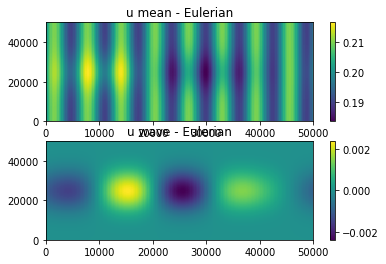

In [187]:
plt.subplot(2,1,1)
plt.pcolor(x,y,U[7*24-1,:,:]-waveE_U[:])
plt.title('u mean - Eulerian')
plt.colorbar()

plt.subplot(2,1,2)
plt.pcolor(x,y,waveE_U[:])
plt.title('u wave - Eulerian');
plt.colorbar()

Final plot for this example:

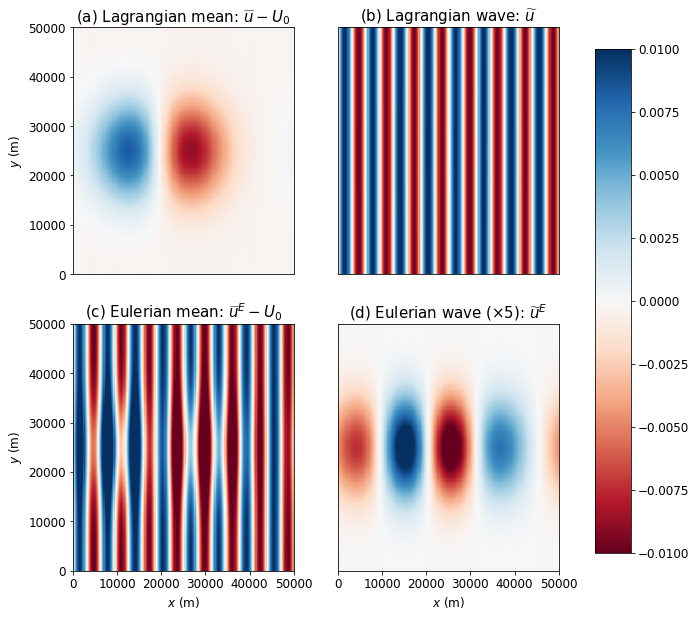

In [226]:
fig1=plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.pcolor(x,y,U[7*24-1,:,:]-wave_U[:]-U0,vmin=-0.01,vmax=0.01,cmap='RdBu')
plt.title(r'(a) Lagrangian mean: $\widebar{u}-U_0$',fontsize=15)
plt.xticks([])
plt.tick_params(labelsize=12)
plt.ylabel(r'$y$ (m)',fontsize=12)

plt.subplot(2,2,2)
plt.pcolor(x,y,wave_U[:],vmin=-0.01,vmax=0.01,cmap='RdBu')
plt.title(r'(b) Lagrangian wave: $\widetilde{u}$',fontsize=15)
plt.xticks([])
plt.yticks([])
plt.tick_params(labelsize=12)

plt.subplot(2,2,3)
plt.pcolor(x,y,U[7*24-1,:,:]-waveE_U[:]-U0,vmin=-0.01,vmax=0.01,cmap='RdBu')
plt.title(r'(c) Eulerian mean: $\widebar{u}^E-U_0$',fontsize=15)
plt.tick_params(labelsize=12)
plt.ylabel(r'$y$ (m)',fontsize=12)
plt.xlabel(r'$x$ (m)',fontsize=12)

plt.subplot(2,2,4)
im=plt.pcolor(x,y,5*waveE_U[:],vmin=-0.01,vmax=0.01,cmap='RdBu')
plt.title('u wave');
plt.title(r'(d) Eulerian wave ($\times$5): $\widetilde{u}^E$',fontsize=15);
plt.yticks([])
plt.tick_params(labelsize=12)
plt.xlabel(r'$x$ (m)',fontsize=12)

plt.subplots_adjust(right=0.8)
cbar_ax = fig1.add_axes([0.85, 0.15, 0.05, 0.7])
plt.colorbar(im, cax=cbar_ax)
plt.tick_params(labelsize=12)

In [228]:
fig1.savefig('analytic_example.pdf', dpi=600)

In [229]:
fig1.savefig('analytic_example.eps', dpi=600)